В данной работе рассматривается задача обнаружения аномалий (Anomaly Detection) в наборе данных, содержащем финансовые показатели банков.

Цель работы: примененить алгоритмы LOF и Isolation Forest для поиска аномалий и проанализировать их результаты.

В качестве исходных данных использовался файл banks.txt, содержащий информацию о банках и их финансовых показателях:

Assets - активы банка

OwnCapital - собственный капитал

IndFunds - средства физических лиц

NBSLoans - кредиты нефинансовому сектору

IndLoans - кредиты физическим лицам

Столбец с названиями банков носит категориальный характер и не используется в моделях.

In [1]:
import pandas as pd
import numpy as np

# Загрузка файла (в Colab сначала загрузите файл вручную)
from google.colab import files
uploaded = files.upload()

# Чтение файла
df = pd.read_csv('banks.txt', encoding='cp1251', sep=',')

# Просмотр данных
print(df.head())

# Удаляем столбец с названиями банков
df_numeric = df.drop(columns=['Bank'])

# Проверим пропуски
print(df_numeric.isnull().sum())

Saving banks.txt to banks.txt
               Bank  Assents  OwnCapital  IndFunds  NBSLoans  IndLoans
0        «Авангард»   122109       20440     35443     32728      3319
1           «Аверс»   110741       24410     34918     13613      4924
2           «Агора»     1114         356       274       351       206
3  «Агропромкредит»    18774        2332     12047      6484       903
4         «Агророс»     7917        1157      3564      1909       492
Assents       0
OwnCapital    0
IndFunds      0
NBSLoans      0
IndLoans      0
dtype: int64


Перед применением алгоритмов были выполнены следующие шаги:

1. Удалён категориальный признак (название банка).

2. Проверено отсутствие пропущенных значений.

Также необходимо выполнить масштабирование признаков с помощью StandardScaler. Масштабирование необходимо, так как алгоритмы, основанные на расстояниях (например, LOF), чувствительны к масштабу данных.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)

Алгоритм Local Outlier Factor (LOF) определяет аномалии на основе локальной плотности объектов.

Идея метода:

Для каждой точки оценивается плотность её окрестности,
затем она сравнивается с плотностью соседей,
если плотность существенно ниже, то объект считается аномалией.

Применим алгоритм с параметрами по умолчанию (novelty=False). Это означает, что он обучается и предсказывает аномалии на одном и том же наборе данных (обучающая выборка = тестовая)

Результатом работы является разметка объектов:

1 - нормальные наблюдения

-1 - аномалии

In [3]:
from sklearn.neighbors import LocalOutlierFactor

# LOF в стандартном режиме
lof = LocalOutlierFactor()

y_pred_lof = lof.fit_predict(X)

# -1 = аномалия, 1 = норм
df['LOF_outlier'] = y_pred_lof

n_lof = (y_pred_lof == -1).sum()
print("\nЧисло аномалий (LOF):", n_lof)


Число аномалий (LOF): 77


77 аномалий могут указывать на то, что многие банки имеют нестандартное соотношение финансовых показателей (например, очень малый капитал при больших активах, или отрицательный капитал).

Далее решим задачу обнаружения новизны (novelty detection):

1. Из выборки удалим найденные аномалии.

2. Модель обучим только на нормальных данных.

3. Используем режим novelty=True. Эта модель определяет, является ли новый объект \"новинкой\" (аномалией) относительно ранее виденных нормальных данных

In [4]:
# Оставляем только нормальные объекты
X_clean = X[y_pred_lof == 1]

# Обучаем LOF в режиме novelty=True
lof_novelty = LocalOutlierFactor(novelty=True)

lof_novelty.fit(X_clean)

X_outliers = X[y_pred_lof == -1]

y_pred_novelty = lof_novelty.predict(X_outliers)

# Сколько снова признаны аномалиями
matches = (y_pred_novelty == -1).sum()

print("Совпадений аномалий:", matches)

Совпадений аномалий: 77


Метод Isolation Forest

Алгоритм Isolation Forest основан на следующей идее:

Аномалии легче изолировать случайными разбиениями,
нормальные объекты требуют большего числа разбиений.

Метод строит ансамбль случайных деревьев.

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(random_state=42)

iso.fit(X)

y_iso = iso.predict(X)

df['ISO_outlier'] = y_iso

# Число аномалий
n_iso = np.sum(y_iso == -1)

print("Число аномалий (Isolation Forest):", n_iso)

Число аномалий (Isolation Forest): 30


Полученное количество аномалий существенно меньше по сравнению с LOF. Это объясняется особенностями метода: Isolation Forest выявляет аномалии на основе сложности их изоляции в случайных деревьях.

Алгоритм, как правило, выделяет наиболее выраженные выбросы и экстремальные значения признаков.

Меньшее число аномалий говорит о том, что метод более консервативен и ориентирован на выявление только наиболее явных отклонений.

Метрики качества в Anomaly Detection

В задачах поиска аномалий часто нет истинных меток, поэтому метрики применяются если есть разметка или создаётся искусственно.

Будем считать, что результаты LOF являются истиной и сравним его с Isolation Forest.


Precision, Recall, F1-score:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       294
           1       0.87      0.34      0.49        77

    accuracy                           0.85       371
   macro avg       0.86      0.66      0.70       371
weighted avg       0.85      0.85      0.82       371



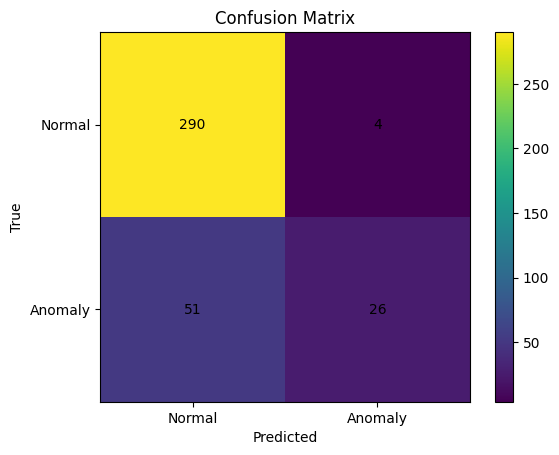

ROC-AUC: 0.7984583443767117
Jaccard similarity: 0.32098765432098764


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, jaccard_score
import matplotlib.pyplot as plt

# Преобразование формата:
# LOF -> "истина"
y_true = (y_pred_lof == -1).astype(int)

# Isolation Forest -> предсказание
y_pred = (y_iso == -1).astype(int)

# =========================================
# 1. Precision, Recall, F1-score
# =========================================

print("\nPrecision, Recall, F1-score:")
print(classification_report(y_true, y_pred))

# =========================================
# 2. Confusion Matrix
# =========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ['Normal', 'Anomaly'])
plt.yticks([0,1], ['Normal', 'Anomaly'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================================
# 3. ROC-AUC
# =========================================

scores_iso = iso.decision_function(X)
roc_auc = roc_auc_score(y_true, -scores_iso)

print("ROC-AUC:", roc_auc)

# =========================================
# 4. Jaccard similarity
# =========================================

jaccard = jaccard_score(y_true, y_pred)

print("Jaccard similarity:", jaccard)

1. Precision (точность). Доля правильно найденных аномалий среди всех найденных.

Для класса аномалий (1) Precision = 0.87

Это означает, что из всех объектов, которые Isolation Forest определил как аномалии,
87% действительно являются аномалиями (по LOF)

Вывод:

Алгоритм редко ошибается, когда говорит "это аномалия",
то есть даёт качественные (точные) срабатывания.

2. Recall (полнота). Доля найденных аномалий среди всех реальных.

Recall для аномалий = 0.34

Это означает, что из всех реальных аномалий (77) найдено только 34%

Вывод:

Алгоритм пропускает много аномалий (51 объект). Isolation Forest ловит только самые явные выбросы.

3. F1-score (гармоническое среднее)

F1 = 0.49

Невысокое значение объясняется хорошей точностью (Precision), но слабой полнотой (Recall)

4. Confusion Matrix

290 - правильно найденные нормальные объекты

4 - ложные срабатывания

51 - пропущенные аномалии (ключевая проблема)

26 - найденные аномалии

Главная проблема — большое число пропущенных аномалий.

5. ROC-AUC

ROC-AUC = 0.798

Вывод:

значение близко к 0.8 - хорошее качество, модель умеет разделять классы

6. Jaccard similarity. Показывает насколько совпадают множества аномалий.

Jaccard = 0,32

Метрика Jaccard similarity используется для оценки схожести множеств найденных аномалий.
Она показывает долю пересечения между истинными и предсказанными аномалиями относительно их объединения.

Невысокое значение Jaccard свидетельствует о том, что алгоритмы обнаруживают различные подмножества аномалий, что обусловлено различиями в их подходах.

Общий вывод:

В ходе работы были исследованы методы обнаружения аномалий на основе банковских данных с использованием алгоритмов Local Outlier Factor (LOF) и Isolation Forest.

Алгоритм LOF, основанный на анализе локальной плотности, выявил большее число аномалий, что свидетельствует о его чувствительности к структуре данных и способности обнаруживать как явные, так и менее выраженные отклонения.

В свою очередь, Isolation Forest показал более консервативный подход, выявляя преимущественно наиболее выраженные выбросы. Это подтверждается меньшим числом найденных аномалий и результатами метрик качества: высокая точность (Precision) при низкой полноте (Recall) указывает на то, что алгоритм хорошо определяет аномалии, но пропускает значительную их часть.

Анализ метрик качества, включая F1-score, ROC-AUC и Jaccard similarity, показал, что алгоритмы частично согласуются между собой, однако выявляют различные подмножества аномалий. Это обусловлено различиями в их математических подходах: LOF использует локальные оценки плотности, тогда как Isolation Forest основывается на случайных разбиениях пространства признаков.

Таким образом, результаты работы подтверждают, что для более надёжного обнаружения аномалий целесообразно использовать несколько алгоритмов одновременно, так как каждый из них выявляет различные типы отклонений. Комплексный подход позволяет получить более полное представление о структуре данных и повысить качество анализа.